# Aurora Visibility — Data Pipeline

Builds a clean, analysis-ready dataset from three raw inputs:

| Input | Source | What we keep |
|---|---|---|
| Aurora sightings | citizen science CSV [(Aurorasaurus Web Observations (2014-2025))](https://zenodo.org/records/16783265) | `obs_id`, `timestamp`, `lat/lon`, `mlat/mlt`, `see_aurora` |
| Geomagnetic indices | OMNI2 / SPDF (fetched)  | `kp`, `bz_gsm`, `sigma_bz_gsm`, `ap`, `solar_wind_speed` |
| Weather | Open-Meteo CSV (pre-fetched) | `cloud_cover`, `visibility`, `moon_phase`, `moon_darkness` |

Please check the [O M N I 2  DATA SET for geomagnetic and solar activity indices](https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2.text) recorded [here](https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/).

Solar geometry (`sun_elevation`, darkness flags) is computed analytically using `astral`.

**Output:** `aurora_dataset_clean.csv` — one row per observation, trimmed to modelling columns only.

---
**Dependencies:** `pandas`, `numpy`, `astral`, `urllib` (stdlib)

# Acknowledgements:

We acknowledge use of NASA/GSFC's Space Physics Data Facility's OMNIWeb (or CDAWeb or ftp) service, and OMNI data. 
[King, J.H. and N.E. Papitashvili, Solar wind spatial scales in and comparisons of hourly Wind and ACE plasma and magnetic field data, J. Geophys. Res., 110, A02104, 2005.](https://dx.doi.org/10.1029/2004JA010649)

Aurorasaurus citizen science data is a collection of auroral sightings submitted to the project via its website (aurorasaurus.org). We acknowledge using Aurorasaurus Web Observations (2014-2025). 
MacDonald, E., New Mexico Consortium, Brandt Edson, L., & Natsheh, F. (2026). [Aurorasaurus Web Observations (2014-2025) (v1.0 - paper) [Data set]. Zenodo.](https://doi.org/10.5281/zenodo.16783265)
 

## 0  Configuration

In [1]:
import io
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
from astral import Observer
from astral.sun import elevation as sun_elevation_fn

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path('.')                              # directory of this notebook

SIGHTINGS_CSV = Path('/home/turbosis/Documents/Work/erodos2026ds/erodosproject/data/data1425/web_observations_2014-08-01_to_2025-08-02_cleaned.csv')
WEATHER_CSV   = DATA_DIR / 'aurora_weather.csv'    # pre-fetched Open-Meteo data
OUTPUT_CSV    = DATA_DIR / 'aurora_dataset_clean.csv'

OMNI2_CACHE   = DATA_DIR / 'omni2_geomagnetic.csv' # written by Section 2

# ── Date range (inclusive) ─────────────────────────────────────────────────────
START_DATE = '2014-10-01'
END_DATE   = '2025-07-31'

# ── OMNI2 column indices (0-based) ─────────────────────────────────────────────
OMNI2_BASE_URL  = 'https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_{year}.dat'
COL_YEAR, COL_DOY, COL_HOUR = 0, 1, 2
COL_BZ_GSM      = 16    # Bz GSM, nT           fill 999.9
COL_SIGMA_BZ    = 21    # Sigma Bz, nT          fill 999.9
COL_SW_SPEED    = 24    # Plasma flow speed km/s fill 9999.9
COL_KP          = 38    # Kp × 10 (quasi-log)   fill 99
COL_AP          = 49    # 3-hourly ap (linear)  fill 999

FILL_BZ  = 999.9
FILL_SW  = 9999.9
FILL_KP  = 99
FILL_AP  = 999

# ── Final output columns (in order) ───────────────────────────────────────────
# ap : 3-hourly linear ap index from OMNI2 column 49 (one value per kp_3hr_bucket)
# Ap : daily planetary A-index = arithmetic mean of the 8 3-hourly ap values,
#      computed on the linear scale directly — NOT derived from Kp averages.
#      Kp is quasi-logarithmic and must NOT be averaged before conversion.
OUTPUT_COLS = [
    'obs_id', 'utc_dt', 'date', 'latitude', 'longitude', 'mlat', 'mlt',
    'see_aurora',
    'kp_3hr_bucket',
    'kp', 'bz_gsm', 'sigma_bz_gsm',
    'ap',                     # 3-hourly linear ap for this observation's bucket
    'Ap',                     # daily Ap = mean of 8 3-hourly ap values (linear average)
    'solar_wind_speed',
    'cloud_cover', 'visibility', 'moon_phase', 'moon_darkness',
    'sun_elevation_utc',       'astronomical_dark_utc',
    'sun_elevation_localtime', 'astronomical_dark_localtime',
]

## 1  Aurora Sightings

Expects `aurora_sightings.csv` with columns:
`obs_id`, `timestamp` (ISO8601 UTC), `location` (WKT point `(lon lat)`),
`mlat`, `mlt`, `see_aurora` (bool).

In [2]:
obs = pd.read_csv(SIGHTINGS_CSV)

# st_x / st_y are geographic longitude / latitude — rename and drop originals
obs = obs.rename(columns={'st_x': 'longitude', 'st_y': 'latitude'})

# Parse timestamp → UTC datetime components
ts = pd.to_datetime(obs['timestamp'], format='ISO8601', utc=True)
obs['utc_dt']  = ts
obs['date']    = ts.dt.date
obs['hour']    = ts.dt.hour
obs['minute']  = ts.dt.minute
obs['second']  = ts.dt.second

# 3-hour Kp bucket: 0=00–02 UT, 1=03–05 UT, …, 7=21–23 UT
obs['kp_3hr_bucket'] = obs['hour'] // 3

# Filter to requested date range
obs = obs[(obs['date'] >= pd.Timestamp(START_DATE).date()) &
          (obs['date'] <= pd.Timestamp(END_DATE).date())].copy()

print(f'Observations loaded : {len(obs):,}')
print(f'Columns             : {obs.shape[1]}')
print(f'Date range          : {obs["date"].min()} → {obs["date"].max()}')
print(f'see_aurora=True     : {obs["see_aurora"].sum():,} ({obs["see_aurora"].mean()*100:.1f}%)')

Observations loaded : 22,280
Columns             : 39
Date range          : 2014-10-01 → 2025-07-31
see_aurora=True     : 16,368 (73.5%)


## 2  OMNI2 Geomagnetic Data

Downloads OMNI2 hourly files from SPDF for each year, extracts Kp, Bz GSM, Sigma Bz,
ap (daily average), and solar wind speed, then aggregates to 3-hour buckets to match
the Kp reporting interval.

Results are cached to `omni2_geomagnetic.csv`; re-run is skipped if the cache exists.

In [3]:
if OMNI2_CACHE.exists():
    print(f'Loading OMNI2 cache: {OMNI2_CACHE}')
    omni2 = pd.read_csv(OMNI2_CACHE, parse_dates=['date'])
    omni2['date'] = omni2['date'].dt.date

else:
    years = range(
        pd.Timestamp(START_DATE).year,
        pd.Timestamp(END_DATE).year + 1
    )
    rows = []
    for year in years:
        url = OMNI2_BASE_URL.format(year=year)
        print(f'Fetching {url} ...', end=' ', flush=True)
        try:
            with urllib.request.urlopen(url, timeout=120) as resp:
                raw = resp.read().decode('ascii', errors='replace')
        except Exception as exc:
            print(f'ERROR: {exc}')
            continue

        for line in raw.splitlines():
            parts = line.split()
            if len(parts) < 55:
                continue
            try:
                rows.append((
                    int(parts[COL_YEAR]),
                    int(parts[COL_DOY]),
                    int(parts[COL_HOUR]),
                    float(parts[COL_BZ_GSM]),
                    float(parts[COL_SIGMA_BZ]),
                    float(parts[COL_SW_SPEED]),
                    int(parts[COL_KP]),
                    int(parts[COL_AP]),
                ))
            except ValueError:
                continue
        print(f'{len(rows):,} rows so far')

    raw_df = pd.DataFrame(
        rows, columns=['year','doy','hour','bz_gsm','sigma_bz','sw_speed','kp_raw','ap_raw']
    )

    raw_df['date'] = pd.to_datetime(
        raw_df['year'].astype(str) + raw_df['doy'].astype(str).str.zfill(3),
        format='%Y%j'
    ).dt.date

    raw_df = raw_df[
        (raw_df['date'] >= pd.Timestamp(START_DATE).date()) &
        (raw_df['date'] <= pd.Timestamp(END_DATE).date())
    ].copy()

    # Replace fill values with NaN
    raw_df.loc[raw_df['bz_gsm']   >= FILL_BZ,  'bz_gsm']   = np.nan
    raw_df.loc[raw_df['sigma_bz'] >= FILL_BZ,  'sigma_bz']  = np.nan
    raw_df.loc[raw_df['sw_speed'] >= FILL_SW,  'sw_speed']  = np.nan
    raw_df.loc[raw_df['kp_raw']   >= FILL_KP,  'kp_raw']    = np.nan
    raw_df.loc[raw_df['ap_raw']   >= FILL_AP,  'ap_raw']    = np.nan

    raw_df['kp']            = raw_df['kp_raw'] / 10.0
    raw_df['kp_3hr_bucket'] = raw_df['hour'] // 3

    # ── Aggregate hourly → 3-hour buckets ─────────────────────────────────────
    # Kp is quasi-logarithmic and constant within each 3-hr period → first value.
    # ap (col 49) is already on the linear scale → first value per bucket.
    # Bz, Sigma Bz, SW speed → mean of the 3 hourly readings within each bucket.
    omni2_3hr = (
        raw_df.groupby(['date', 'kp_3hr_bucket'])
        .agg(
            kp               = ('kp',       'first'),
            bz_gsm           = ('bz_gsm',   'mean'),
            sigma_bz_gsm     = ('sigma_bz', 'mean'),
            solar_wind_speed = ('sw_speed', 'mean'),
            ap               = ('ap_raw',   'first'),  # 3-hourly linear ap
        )
        .reset_index()
    )

    # ── Daily Ap (capital) ────────────────────────────────────────────────────
    # Ap = arithmetic mean of the 8 3-hourly ap values per day.
    # This averaging is done on the LINEAR ap scale, not on Kp.
    # Converting Kp→ap first then averaging is the correct procedure;
    # averaging Kp (quasi-log) and converting afterwards would be wrong.
    Ap_daily = (
        omni2_3hr.groupby('date')['ap']
        .mean()
        .rename('Ap')
        .reset_index()
    )

    omni2 = omni2_3hr.merge(Ap_daily, on='date', how='left')

    omni2.to_csv(OMNI2_CACHE, index=False)
    print(f'\nSaved {len(omni2):,} rows → {OMNI2_CACHE}')

print(f'OMNI2 rows           : {len(omni2):,}')
print(f'kp range             : {omni2["kp"].min():.1f} – {omni2["kp"].max():.1f}')
print(f'ap range (3-hourly)  : {omni2["ap"].min():.0f} – {omni2["ap"].max():.0f} nT')
print(f'Ap range (daily)     : {omni2["Ap"].min():.1f} – {omni2["Ap"].max():.1f} nT')
print(f'bz_gsm NaN           : {omni2["bz_gsm"].isna().sum():,}')
print(f'solar_wind_speed NaN : {omni2["solar_wind_speed"].isna().sum():,}')

Loading OMNI2 cache: omni2_geomagnetic.csv
OMNI2 rows           : 31,656
kp range             : 0.0 – 9.0
ap range (3-hourly)  : 0 – 400 nT
Ap range (daily)     : 0.0 – 270.8 nT
bz_gsm NaN           : 97
solar_wind_speed NaN : 0


### 2.1  Merge geomagnetic data into observations

In [4]:
# Drop any geomagnetic columns from a previous run before merging
_geo_cols = ['kp', 'bz_gsm', 'sigma_bz_gsm', 'solar_wind_speed', 'ap', 'Ap']
obs = obs.drop(columns=[c for c in _geo_cols if c in obs.columns])

obs = obs.merge(
    omni2,
    on=['date', 'kp_3hr_bucket'],
    how='left'
)

print(f'After geomagnetic merge : {obs.shape}')
for col in ['kp', 'bz_gsm', 'sigma_bz_gsm', 'ap', 'Ap', 'solar_wind_speed']:
    label = f'{col} (3-hourly linear)'          if col == 'ap' else \
            f'{col} (daily mean of 8×ap, linear)' if col == 'Ap' else col
    print(f'  {label:<42} null: {obs[col].isna().sum():>5}')

After geomagnetic merge : (22280, 45)
  kp                                         null:     0
  bz_gsm                                     null:    78
  sigma_bz_gsm                               null:    75
  ap (3-hourly linear)                       null:     0
  Ap (daily mean of 8×ap, linear)            null:     0
  solar_wind_speed                           null:     0


## 3  Weather Data

Expects `aurora_weather.csv` with columns: `obs_id`, `cloud_cover` (%), `visibility` (km),
`moon_phase` (0=new moon, 0.5=full moon, 1=new moon), `moon_darkness` (sky darkness proxy).

This file is sourced from Open-Meteo historical archive (`archive-api.open-meteo.com`).
See `fetch_weather.py` for the collection script.

In [5]:
weather = pd.read_csv(
    WEATHER_CSV,
    usecols=['obs_id', 'cloud_cover', 'visibility', 'moon_phase', 'moon_darkness']
)

# Drop weather columns if already present from a previous run
_wx_cols = ['cloud_cover', 'visibility', 'moon_phase', 'moon_darkness']
obs = obs.drop(columns=[c for c in _wx_cols if c in obs.columns])

obs = obs.merge(weather, on='obs_id', how='left')

print(f'After weather merge     : {obs.shape}')
for col in _wx_cols:
    print(f'  {col:<20} null: {obs[col].isna().sum():>5}')

After weather merge     : (22280, 49)
  cloud_cover          null:     0
  visibility           null:     0
  moon_phase           null:     0
  moon_darkness        null:     0


## 4  Solar Geometry

Sun elevation is computed analytically at the observer's exact lat/lon and UTC datetime
using the `astral` library.

Two variants are computed:
- **UTC**: uses the stored timestamp as-is (assumed UTC)
- **local time**: corrects for possible timezone confusion — some observers may have
  submitted timestamps in local time rather than UTC. The offset is estimated as
  `round(longitude / 15)` hours (solar mean time).

Astronomical darkness threshold: sun elevation < −18°.

In [6]:
utc_dts = pd.to_datetime(obs['utc_dt'], utc=True)

# Local-time correction: if stored timestamp is actually local time,
# true UTC = stored_time − estimated_offset
utc_offset_h = (obs['longitude'] / 15).round().clip(-12, 12).astype(int)
localtime_dts = utc_dts - pd.to_timedelta(utc_offset_h, unit='h')

elev_utc   = []
elev_local = []

for i in range(len(obs)):
    observer = Observer(
        latitude  = obs['latitude'].iat[i],
        longitude = obs['longitude'].iat[i]
    )
    elev_utc.append(sun_elevation_fn(observer, utc_dts.iat[i]))
    elev_local.append(sun_elevation_fn(observer, localtime_dts.iat[i]))

obs['sun_elevation_utc']         = elev_utc
obs['astronomical_dark_utc']     = obs['sun_elevation_utc'] < -18
obs['sun_elevation_localtime']   = elev_local
obs['astronomical_dark_localtime'] = obs['sun_elevation_localtime'] < -18

print('Sun elevation computed.')
print(f'  astronomical_dark_utc=True       : {obs["astronomical_dark_utc"].sum():,}')
print(f'  astronomical_dark_localtime=True : {obs["astronomical_dark_localtime"].sum():,}')
print()
print('Physically inconsistent rows (see_aurora=True but sun up under both assumptions):')
impossible = (
    (obs['see_aurora'] == True) &
    (obs['sun_elevation_utc'] >= -18) &
    (obs['sun_elevation_localtime'] >= -18)
)
print(f'  {impossible.sum():,} rows')

Sun elevation computed.
  astronomical_dark_utc=True       : 11,391
  astronomical_dark_localtime=True : 8,815

Physically inconsistent rows (see_aurora=True but sun up under both assumptions):
  5,940 rows


## 5  Final Dataset

Select the modelling columns, run a final consistency check, and save.

In [7]:
# Verify all modelling columns are present
missing = [c for c in OUTPUT_COLS if c not in obs.columns]
if missing:
    raise ValueError(f'Missing expected columns: {missing}')

# Save the full dataframe — all original sightings columns plus every derived column.
# OUTPUT_COLS documents the modelling subset but nothing is dropped here.
final = obs.copy()

# ── Data quality summary ───────────────────────────────────────────────────────
print(f'Final shape : {final.shape}')
print(f'All columns : {final.columns.tolist()}')
print()
print('Null counts in modelling columns:')
nulls = final[OUTPUT_COLS].isna().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else '  none')
print()
print('Class balance (see_aurora):')
print(final['see_aurora'].value_counts(normalize=True).round(3))

Final shape : (22280, 53)
All columns : ['raw_row_num', 'obs_id', 'activities_id', 'height_id', 'sky_id', 'observer_id', 'timestamp', 'address_country', 'address_state', 'location', 'see_aurora', 'sky_other', 'time_start', 'time_end', 'on_going', 'height_other', 'activities_other', 'colors_other', 'types_other', 'comment', 'image', 'latitude', 'longitude', 'colors', 'types', 'image_url', 'small_image_url', 'redact_row', 'pii_redacted', 'duration', 'mlat', 'mlon', 'mlt', 'utc_dt', 'date', 'hour', 'minute', 'second', 'kp_3hr_bucket', 'kp', 'bz_gsm', 'sigma_bz_gsm', 'solar_wind_speed', 'ap', 'Ap', 'cloud_cover', 'visibility', 'moon_phase', 'moon_darkness', 'sun_elevation_utc', 'astronomical_dark_utc', 'sun_elevation_localtime', 'astronomical_dark_localtime']

Null counts in modelling columns:
mlat            16
mlt             16
bz_gsm          78
sigma_bz_gsm    75

Class balance (see_aurora):
see_aurora
True     0.735
False    0.265
Name: proportion, dtype: float64


In [8]:
# ── Save ───────────────────────────────────────────────────────────────────────
final.to_csv(OUTPUT_CSV, index=False)
print(f'Saved {len(final):,} rows × {final.shape[1]} cols → {OUTPUT_CSV}')

Saved 22,280 rows × 53 cols → aurora_dataset_clean.csv


## 6  Quick Sanity Checks

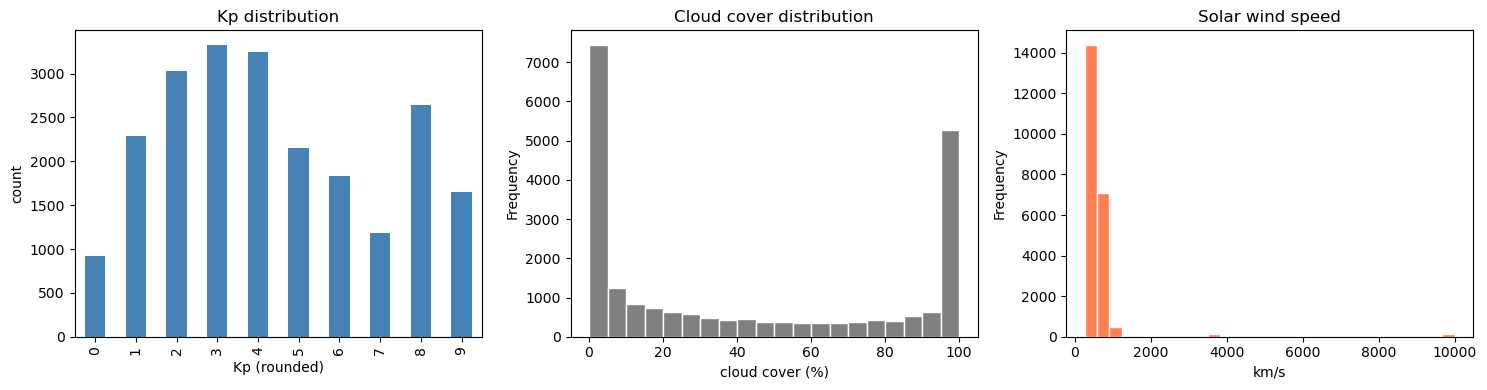

             kp    bz_gsm        ap  solar_wind_speed  cloud_cover  sun_elevation_utc
count  22280.00  22202.00  22280.00          22280.00     22280.00           22280.00
mean       4.37     -3.68     75.40            630.88        42.13             -10.09
std        2.58      7.24     98.84            824.24        41.31              31.40
min        0.00    -29.93      0.00            262.00         0.00             -86.02
25%        2.30     -6.77      9.00            415.33         1.00             -31.55
50%        4.00     -1.73     27.00            500.33        27.00             -18.43
75%        6.30      0.90     94.00            682.33        92.00               9.42
max        9.00     26.90    400.00           9999.00       100.00              86.47


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Kp distribution
final['kp'].dropna().round().astype(int).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set(title='Kp distribution', xlabel='Kp (rounded)', ylabel='count')

# Cloud cover
final['cloud_cover'].dropna().plot(
    kind='hist', bins=20, ax=axes[1], color='grey', edgecolor='white'
)
axes[1].set(title='Cloud cover distribution', xlabel='cloud cover (%)')

# Solar wind speed
final['solar_wind_speed'].dropna().plot(
    kind='hist', bins=30, ax=axes[2], color='coral', edgecolor='white'
)
axes[2].set(title='Solar wind speed', xlabel='km/s')

plt.tight_layout()
plt.show()

print(final[['kp','bz_gsm','ap','solar_wind_speed',
             'cloud_cover','sun_elevation_utc']].describe().round(2).to_string())